In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
%pip install -q transformers accelerate datasets pillow peft pandas pyarrow bitsandbytes trl deep-translator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 518.9/518.9 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 4.5 MB/s eta 0:00:00


In [3]:
import os
import sys
import json
import warnings
from pathlib import Path
from io import BytesIO
from typing import Dict, List


os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
warnings.filterwarnings('ignore')


import torch
from transformers import (
    Qwen2VLForConditionalGeneration,
    AutoProcessor,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)
from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)


import pandas as pd
from datasets import Dataset
from PIL import Image

print("Kütüphaneler yüklendi!")

Kütüphaneler yüklendi!


In [ ]:
chatbot_data = []

def is_valid_text(text):
    if not text:
        return False

    text = str(text).strip()
    text_lower = text.lower()

    invalid_keywords = ["unknown", "bilinmiyor", "none", "nan", "null", "undefined"]

    if len(text) < 3: return False
    if text_lower in invalid_keywords: return False

    if text_lower == "yemek": return False

    if text.isdigit(): return False

    return True

print("--- 1. Chatbot Sohbet Verileri Yükleniyor ve Temizleniyor ---")
chat_file_path = '/content/drive/MyDrive/colab_data/train_data_chat.jsonl'
if os.path.exists(chat_file_path):
    try:
        with open(chat_file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line: continue
                try:
                    entry = json.loads(line)

                    valid_entry = True
                    for msg in entry.get("messages", []):
                        content = msg.get("content", "")

                        if isinstance(content, list):
                            text_content = ""
                            for part in content:
                                if part.get("type") == "text":
                                    text_content += part.get("text", "")
                            content = text_content

                        if not is_valid_text(content):
                            valid_entry = False
                            break

                    if valid_entry:
                        chatbot_data.append(entry)
                except: pass
        print(f"Chat verisi yüklendi: {len(chatbot_data)} örnek")
    except Exception as e: print(f" Dosya okuma hatası: {e}")
else:
    print(f" {chat_file_path} bulunamadı!")



print("\n--- 3. Ekstra Metin Verileri (Codatta / Food101) ---")
dataset_candidates = [
    ("Codatta/MM-Food-100K", "caption"),
    ("food101", "label")
]

cd_count = 0
TARGET_LIMIT = 500

for ds_name, text_key in dataset_candidates:
    if cd_count >= TARGET_LIMIT: break
    print(f"deneniyor: {ds_name}...")
    try:
        ds = load_dataset(ds_name, split="train", streaming=True, trust_remote_code=True)

        for i, example in enumerate(ds):
            if cd_count >= TARGET_LIMIT: break
            if i > 1500: break

            text = None
            if text_key in example:
                text = example[text_key]
            elif 'text' in example:
                text = example['text']

            if is_valid_text(text):
                chatbot_data.append({
                    "messages": [
                        {"role": "user", "content": "Bu yemek hakkında bilgi ver."},
                        {"role": "assistant", "content": str(text)}
                    ]
                })
                cd_count += 1
    except Exception as e:
        print(f"{ds_name} ile veri çekilemedi: {e}")

print(f"Ekstra kaynaklardan {cd_count} açıklama eklendi.")
print(f"\nTOPLAM CHATBOT EĞİTİM VERİSİ: {len(chatbot_data)} örnek")

--- 1. Chatbot Sohbet Verileri Yükleniyor ve Temizleniyor ---
Chat verisi yüklendi: 201 örnek

--- 3. Ekstra Metin Verileri (Codatta / Food101) ---
deneniyor: Codatta/MM-Food-100K...
Codatta/MM-Food-100K ile veri çekilemedi: name 'load_dataset' is not defined
deneniyor: food101...
food101 ile veri çekilemedi: name 'load_dataset' is not defined
Ekstra kaynaklardan 0 açıklama eklendi.

TOPLAM CHATBOT EĞİTİM VERİSİ: 201 örnek


In [ ]:
import os
import io
import json
import pandas as pd
from PIL import Image
from tqdm import tqdm


parquet_folder = "/content/drive/MyDrive/ProjeYusuf/food_nutrients_data"
output_folder = "/content/drive/MyDrive/ProjeYusuf/GenelYemekVerisi"
json_output_path = "/content/drive/MyDrive/ProjeYusuf/parquet_dataset.json"


if not os.path.exists(output_folder):
    os.makedirs(output_folder, exist_ok=True)

print("Parquet dosyalari araniyor...")


if os.path.exists(parquet_folder):
    parquet_files = [f for f in os.listdir(parquet_folder) if f.endswith('.parquet')]
else:
    print(f"⚠️ {parquet_folder} bulunamadı! Varsayılan colab_data klasörüne bakılıyor.")
    parquet_folder = '/content/drive/MyDrive/colab_data'
    parquet_files = [f for f in os.listdir(parquet_folder) if f.endswith('.parquet')]

print(f"Bulunan paket sayisi: {len(parquet_files)}")

dataset_entries = []
total_images = 0

for p_file in parquet_files:
    full_path = os.path.join(parquet_folder, p_file)
    print(f"Paket işleniyor: {p_file}...")

    try:
        df = pd.read_parquet(full_path)

        for index, row in tqdm(df.iterrows(), total=df.shape[0]):
            try:

                if row['image'] is None or 'bytes' not in row['image']:
                    continue

                image_bytes = row['image']['bytes']


                image_filename = f"{p_file.replace('.parquet', '')}_{index}.jpg"
                save_path = os.path.join(output_folder, image_filename)


                if not os.path.exists(save_path):
                    image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
                    image.save(save_path)


                food_name = "Unknown"
                ingredients = ""


                if 'text' in row and row['text']:
                    food_name = row['text']
                elif 'class' in row and row['class']:
                    food_name = str(row['class'])
                elif 'ingredients' in row:
                    ingr = row['ingredients']
                    if isinstance(ingr, str) and ingr:
                        food_name = ingr.split(',')[0].strip()
                        ingredients = ingr


                calories = row.get('total_calories', 0)

                entry = {
                    'image_path': save_path,
                    'food_name': food_name,
                    'ingredients': ingredients,
                    'calories': calories,
                    'id': row.get('id', str(index))
                }

                dataset_entries.append(entry)
                total_images += 1

            except Exception as e:
                continue
    except Exception as e:
        print(f"Dosya okuma hatası {p_file}: {e}")

# JSON kaydet
with open(json_output_path, 'w', encoding='utf-8') as f:
    json.dump(dataset_entries, f, ensure_ascii=False, indent=2)

print(f"\n İşlem tamamlandı. Toplam {total_images} görsel işlendi.")
print(f"Metadata kaydedildi: {json_output_path}")

Parquet dosyalari araniyor...
⚠️ /content/drive/MyDrive/ProjeYusuf/food_nutrients_data bulunamadı! Varsayılan colab_data klasörüne bakılıyor.
Bulunan paket sayisi: 3
Paket işleniyor: 0002.parquet...


100%|██████████| 760/760 [00:09<00:00, 76.15it/s]


Paket işleniyor: 0000.parquet...


100%|██████████| 1100/1100 [00:00<00:00, 4266.48it/s]


Paket işleniyor: 0001.parquet...


100%|██████████| 1400/1400 [00:00<00:00, 5033.04it/s]



✅ İşlem tamamlandı. Toplam 3260 görsel işlendi.
Metadata kaydedildi: /content/drive/MyDrive/ProjeYusuf/parquet_dataset.json


In [45]:
import os
import json
from datasets import load_dataset
from PIL import Image
from tqdm import tqdm

json_output_path = "/content/drive/MyDrive/ProjeYusuf/parquet_dataset.json"

vision_data = []

if os.path.exists(json_output_path):
    try:
        with open(json_output_path, 'r', encoding='utf-8') as f:
            source_data = json.load(f)
        print(f"JSON dosyasından {len(source_data)} adet yerel veri okundu.")
    except Exception as e:
        print(f"JSON okuma hatası: {e}")
        source_data = []
else:
    source_data = locals().get('dataset_entries', [])
    print(f"Bellekten {len(source_data)} adet veri alındı.")

print("Yerel veriler temizlenip ekleniyor...")
for item in source_data:
    try:
        name = item.get('food_name', '')
        if not name or name in ["Unknown", "str", "Yemek", "None", "nan"]:
            name = "Yemek (Tanımlanmamış)"

        calories = item.get('calories', 0)
        if calories <= 0:
             calories_txt = "Bilinmiyor"
        else:
             min_cal = int(calories * 0.8)
             max_cal = int(calories * 1.2)
             calories_txt = f"{min_cal}-{max_cal} kcal"

        vision_data.append({
            'image_path': item['image_path'],
            'food_name': name,
            'calories_range': calories_txt
        })
    except: continue

print(f"Yerel Veri (Temizlenmiş): {len(vision_data)}")

extra_output_folder = "/content/drive/MyDrive/ProjeYusuf/GenelYemekVerisi/extra_downloads"
os.makedirs(extra_output_folder, exist_ok=True)

print("\n--- Ekstra Görsel Kaynakları ---")
dataset_candidates = [("food101", "label")]

extra_count = 0
TARGET_EXTRA = 500

for ds_name, text_key in dataset_candidates:
    if extra_count >= TARGET_EXTRA: break
    print(f"\nKaynak taranıyor: {ds_name} (Hatasız Mod)")

    try:
        ds = load_dataset(ds_name, split="train", streaming=True)

        for i, example in enumerate(tqdm(ds)):
            if extra_count >= TARGET_EXTRA: break
            if i > 1000: break

            try:
                if 'image' not in example or example['image'] is None:
                    continue

                text_val = "Yemek"
                if text_key in example:
                    val = example[text_key]
                    if isinstance(val, int):
                         text_val = "Bilinmeyen Yemek (Food101)"
                    else:
                         text_val = str(val)
                elif 'text' in example:
                    text_val = example['text']

                img = example['image']
                if img.mode != 'RGB': img = img.convert('RGB')

                fname = f"{ds_name.replace('/', '_')}_{i}.jpg"
                save_path = os.path.join(extra_output_folder, fname)
                if not os.path.exists(save_path):
                    img.save(save_path)

                vision_data.append({
                    'image_path': save_path,
                    'food_name': text_val,
                    'calories_range': "Tahmin Edilecek"
                })
                extra_count += 1
            except: continue
    except Exception as e:
        print(f"{ds_name} yüklenemedi: {e}")

print(f"Ekstra görsel eklendi: {extra_count}")
print(f"\nTOPLAM VİSİON EĞİTİM SETİ: {len(vision_data)} örnek")

JSON dosyasından 3260 adet yerel veri okundu.
Yerel veriler temizlenip ekleniyor...
Yerel Veri (Temizlenmiş): 3260

--- Ekstra Görsel Kaynakları ---

Kaynak taranıyor: food101 (Hatasız Mod)


500it [00:02, 241.05it/s]

Ekstra görsel eklendi: 500

TOPLAM VİSİON EĞİTİM SETİ: 3760 örnek


In [7]:
model_name = "Qwen/Qwen2-VL-7B-Instruct"

print(f"{model_name} modeli (Standart bf16 Modu) yükleniyor...")

import gc
import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from peft import LoraConfig, get_peft_model, TaskType

torch.cuda.empty_cache()
gc.collect()

attn_impl = "sdpa"

try:
    model = Qwen2VLForConditionalGeneration.from_pretrained(
        model_name,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        attn_implementation=attn_impl
    )

    model.gradient_checkpointing_enable()
    model.enable_input_require_grads()

    peft_config = LoraConfig(
        r=16,
        lora_alpha=32,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
        modules_to_save=["embed_tokens", "lm_head"]
    )

    model = get_peft_model(model, peft_config)
    model.print_trainable_parameters()

    print("Model başarıyla yüklendi!")

    processor = AutoProcessor.from_pretrained(model_name)

except Exception as e:
    print(f"Hata: {e}")
    if "out of memory" in str(e).lower():
        print("\nGPU Belleği yetmedi! (OOM). Colab T4 kullanıyorsanız 7B modeli quantization olmadan eğitmek zordur.")
    raise e

Qwen/Qwen2-VL-7B-Instruct modeli (Standart bf16 Modu - BitsAndBytes YOK) yükleniyor...


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

model-00002-of-00005.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

In [36]:

def format_chatbot_data(example):
    """Messages formatını model için uygun şablona çevirir ve System Prompt ekler"""

    if not isinstance(example, dict):
        return {'text': ''}

    messages = example.get('messages', [])
    if not isinstance(messages, list):
        return {'text': ''}


    msgs = list(messages)


    if not msgs or msgs[0].get('role') != 'system':
        msgs.insert(0, {
            "role": "system",
            "content": "Sen yardımsever, motive edici ve bilgili bir diyetisyensin. Kullanıcılara beslenme önerileri verirken kibar ve açıklayıcı ol."
        })


    try:
        text = processor.apply_chat_template(
            msgs,
            tokenize=False,
            add_generation_prompt=False
        )
        return {'text': text}
    except Exception as e:
        return {'text': ''}


print(f"Yüklenen veri sayısı: {len(chatbot_data)}")

formatted_data = []
for item in chatbot_data:
    if isinstance(item, dict) and 'messages' in item:
        formatted_item = format_chatbot_data(item)
        if formatted_item.get('text', '').strip():
            formatted_data.append(formatted_item)

print(f"Formatlanmış (System Prompt Ekli) veri sayısı: {len(formatted_data)}")

if len(formatted_data) == 0:
    raise ValueError("Hiç geçerli veri bulunamadı! Lütfen train_data_chat.jsonl dosyasını kontrol edin.")

chatbot_dataset = Dataset.from_list(formatted_data)
print(f"Dataset hazır. Toplam {len(chatbot_dataset)} örnek.")

Yüklenen veri sayısı: 201
Formatlanmış (System Prompt Ekli) veri sayısı: 201
Dataset hazır. Toplam 201 örnek.


In [37]:
def tokenize_chatbot(examples):
    """Chatbot verilerini tokenize et (Sadeleştirilmiş)"""
    texts = examples['text']

    # Tokenize işlemi (Liste olarak döndür)
    tokenized = processor.tokenizer(
        texts,
        truncation=True,
        max_length=1024,
        padding=False # Padding'i Collator yapacak
    )

    # Verinin düz liste olduğundan emin ol (iç içe listeleri önle)
    input_ids_list = [list(seq) for seq in tokenized['input_ids']]

    return {
        'input_ids': input_ids_list,
        'labels': input_ids_list # Causal LM için labels = input_ids
    }

torch.cuda.empty_cache()

print(f"Orijinal dataset boyutu: {len(chatbot_dataset)}")

# Pad token kontrolü
if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

# Dataseti yeniden işle
tokenized_chatbot = chatbot_dataset.map(
    tokenize_chatbot,
    batched=True,
    batch_size=16,
    remove_columns=chatbot_dataset.column_names
)

print(f"Chatbot dataset tokenize edildi. Toplam {len(tokenized_chatbot)} örnek.")

Orijinal dataset boyutu: 201


Map:   0%|          | 0/201 [00:00<?, ? examples/s]

Chatbot dataset tokenize edildi. Toplam 201 örnek.


In [43]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

chatbot_output_dir = "/content/drive/MyDrive/qwen2vl/checkpoints/chatbot_lora"

chatbot_training_args = TrainingArguments(
    output_dir=chatbot_output_dir,
    num_train_epochs=3,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=32,
    learning_rate=1e-4,
    weight_decay=0.01,
    warmup_ratio=0.05,
    lr_scheduler_type="cosine",
    bf16=True,
    logging_steps=5,
    save_strategy="epoch",
    save_total_limit=2,
    remove_unused_columns=False,
    optim="adamw_torch",
    report_to="none"
)

class ChatbotDataCollator:
    def __call__(self, features):
        import torch

        batch_input_ids = [torch.tensor(f['input_ids'], dtype=torch.long) for f in features]
        batch_labels = [torch.tensor(f['labels'], dtype=torch.long) for f in features]

        pad_id = processor.tokenizer.pad_token_id if processor.tokenizer.pad_token_id is not None else processor.tokenizer.eos_token_id

        padded_input_ids = torch.nn.utils.rnn.pad_sequence(batch_input_ids, batch_first=True, padding_value=pad_id)
        padded_labels = torch.nn.utils.rnn.pad_sequence(batch_labels, batch_first=True, padding_value=-100)

        attention_mask = padded_input_ids.ne(pad_id)

        return {
            'input_ids': padded_input_ids,
            'labels': padded_labels,
            'attention_mask': attention_mask
        }

chatbot_trainer = Trainer(
    model=model,
    args=chatbot_training_args,
    train_dataset=tokenized_chatbot,
    data_collator=ChatbotDataCollator(),
)

In [12]:
def prepare_vision_data(examples):
    images = []

    food_names = []
    cal_ranges = []

    iterator = zip(
        examples["image_path"],
        examples["food_name"],
        examples["calories_range"],
    )

    for img_path, food_name, cal_range in iterator:
        try:
            if img_path is None or not os.path.exists(img_path):
                continue


            img = Image.open(img_path).convert("RGB")

            images.append(img)
            food_names.append(food_name)
            cal_ranges.append(cal_range)

        except Exception as e:
            print(f"Hata ({img_path}): {e}")
            continue

    return {"images": images, "food_name": food_names, "calories_range": cal_ranges}


torch.cuda.empty_cache()

print(f"Toplam görsel veri sayısı: {len(vision_data)}")
vision_dataset = Dataset.from_list(vision_data)


print("Görseller yükleniyor...")
vision_dataset = vision_dataset.map(
    prepare_vision_data,
    batched=True,
    batch_size=32,
    remove_columns=vision_dataset.column_names,
)

print(f"Vision dataset hazırlandı: {len(vision_dataset)} örnek")

Toplam görsel veri sayısı: 3760
Görseller yükleniyor...


Map:   0%|          | 0/3760 [00:00<?, ? examples/s]

Vision dataset hazırlandı: 3760 örnek


In [13]:
def tokenized_vision(example):

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": "Bu yemek görselini analiz et. Yemek adı ve yaklaşık kalori aralığını belirt."},
            ],
        },
        {
            "role": "assistant",
            "content": [
                {"type": "text", "text": f"Yemek: {example['food_name']}, Kalori: {example['calories_range']}"}
            ]
        }
    ]


    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )


    inputs = processor(
        text=[text],
        images=[example["images"]],
        return_tensors="pt",
        padding=False,
        truncation=True,
    )



    input_ids = inputs["input_ids"][0]
    attention_mask = inputs["attention_mask"][0]


    pixel_values = inputs["pixel_values"]
    image_grid_thw = inputs["image_grid_thw"]

    labels = input_ids.clone()
    labels[labels == processor.image_token_id] = -100

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "pixel_values": pixel_values,
        "image_grid_thw": image_grid_thw,
        "labels": labels,
    }

In [14]:
print("Vision verisi YENİDEN tokenize ediliyor (Düzeltilmiş)... this might take a minute")

tokenized_vision_dataset = vision_dataset.map(
    tokenized_vision,
    batched=False,
    remove_columns=vision_dataset.column_names,
)

print(f"Tokenization tamamlandı: {len(tokenized_vision_dataset)} örnek hazır.")

Vision verisi YENİDEN tokenize ediliyor (Düzeltilmiş)... this might take a minute


Map:   0%|          | 0/3760 [00:00<?, ? examples/s]

Tokenization tamamlandı: 3760 örnek hazır.


In [ ]:

vision_output_dir = "/content/drive/MyDrive/qwen2vl/checkpoints/vision_lora"
final_vision_path = "/content/drive/MyDrive/qwen2vl/models/vision_lora_final"
os.makedirs(vision_output_dir, exist_ok=True)
os.makedirs(final_vision_path, exist_ok=True)

vision_training_args = TrainingArguments(
    output_dir=vision_output_dir,
    num_train_epochs=1,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=8,
    learning_rate=1e-4,
    weight_decay=0.01,
    warmup_ratio=0.03,
    bf16=True,
    logging_steps=10,
    save_strategy="steps",
    save_steps=50,
    save_total_limit=2,
    remove_unused_columns=False,
    max_grad_norm=1.0,
    optim="adamw_torch",
    report_to="none",
)


class VisionDataCollator:
    def __call__(self, features):
        import torch

        # Datasets kütüphanesi tensörleri listeye çevirdiği için geri çevirmemiz lazım
        input_ids = [torch.as_tensor(f["input_ids"], dtype=torch.long) for f in features]
        labels = [torch.as_tensor(f["labels"], dtype=torch.long) for f in features]

        input_ids_padded = torch.nn.utils.rnn.pad_sequence(input_ids, batch_first=True, padding_value=processor.tokenizer.pad_token_id)
        labels_padded = torch.nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value=-100)
        attention_mask = input_ids_padded.ne(processor.tokenizer.pad_token_id)

        # Görsel verilerini de tensöre çevirip birleştiriyoruz
        pixel_values = [torch.as_tensor(f["pixel_values"]) for f in features]
        pixel_values = torch.cat(pixel_values, dim=0)

        image_grid_thw = [torch.as_tensor(f["image_grid_thw"]) for f in features]
        image_grid_thw = torch.cat(image_grid_thw, dim=0)

        return {
            "input_ids": input_ids_padded,
            "labels": labels_padded,
            "attention_mask": attention_mask,
            "pixel_values": pixel_values,
            "image_grid_thw": image_grid_thw
        }


vision_trainer = Trainer(
    model=model,
    args=vision_training_args,
    train_dataset=tokenized_vision_dataset,
    data_collator=VisionDataCollator(),
)


torch.cuda.empty_cache()
print(f"Vision LoRA eğitimi başlıyor... Hedef: {final_vision_path}")

try:
    vision_trainer.train()
    vision_trainer.save_model(final_vision_path)
    processor.save_pretrained(final_vision_path)
    print(f"\n LORA EĞİTİMİ TAMAMLANDI! Model Drive'a kaydedildi: {final_vision_path}")
except Exception as e:
    print(f" Vision eğitimi hatası: {e}")

Vision LoRA eğitimi başlıyor... Hedef: /content/drive/MyDrive/qwen2vl/models/vision_lora_final
{'loss': 1.6127, 'grad_norm': 5.830245494842529, 'learning_rate': 9.56140350877193e-05, 'epoch': 0.0851063829787234}
{'loss': 0.1202, 'grad_norm': 8.071474075317383, 'learning_rate': 8.68421052631579e-05, 'epoch': 0.1702127659574468}
{'loss': 0.0719, 'grad_norm': 0.6257225275039673, 'learning_rate': 7.807017543859649e-05, 'epoch': 0.2553191489361702}
{'loss': 0.0696, 'grad_norm': 0.49324288964271545, 'learning_rate': 6.929824561403509e-05, 'epoch': 0.3404255319148936}
{'loss': 0.0706, 'grad_norm': 0.5180525779724121, 'learning_rate': 6.052631578947369e-05, 'epoch': 0.425531914893617}
{'loss': 0.0658, 'grad_norm': 0.5089893937110901, 'learning_rate': 5.1754385964912286e-05, 'epoch': 0.5106382978723404}
{'loss': 0.069, 'grad_norm': 0.297862708568573, 'learning_rate': 4.298245614035088e-05, 'epoch': 0.5957446808510638}
{'loss': 0.0695, 'grad_norm': 0.5960304737091064, 'learning_rate': 3.42105263

--- Vision Model Testi ---
Görsel Yolu: /content/drive/MyDrive/ProjeYusuf/GenelYemekVerisi/0001_759.jpg
Gerçek Yemek Adı: Yemek (Tanımlanmamış)
Gerçek Kalori Aralığı: 176-265 kcal
Model Tahmini: Yemek: Yemek (Tanımlanmamış), Kalori: 295-443 kcal


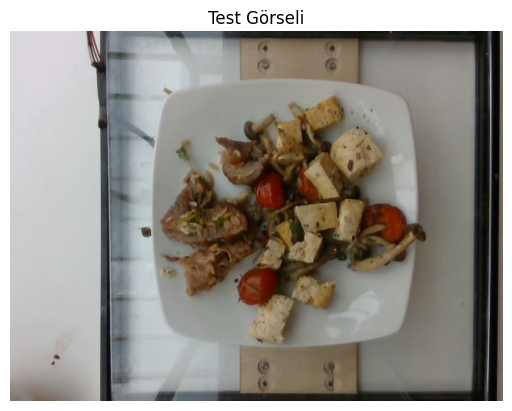

In [19]:
import random
import torch
import matplotlib.pyplot as plt

model.eval()

if len(vision_data) == 0:
    print("Hata: Vision dataset'i boş. Lütfen veri hazırlama adımlarını kontrol edin.")
else:
    # Rastgele bir örnek seç
    sample_vision_entry = random.choice(vision_data)
    image_path = sample_vision_entry['image_path']
    true_food_name = sample_vision_entry['food_name']
    true_calories_range = sample_vision_entry['calories_range']

    try:
        image = Image.open(image_path).convert("RGB")

        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {"type": "text", "text": "Bu yemek görselini analiz et. Yemek adı ve yaklaşık kalori aralığını belirt.",},
                ],
            }
        ]

        text_input = processor.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )

        inputs = processor(
            text=[text_input],
            images=[image],
            return_tensors="pt",
            padding=True,
            truncation=True,
        ).to(model.device)

        with torch.no_grad():
            output_ids = model.generate(**inputs, max_new_tokens=128)

        response_text = processor.decode(output_ids[0][len(inputs['input_ids'][0]):], skip_special_tokens=True)

        print("--- Vision Model Testi ---")
        print(f"Görsel Yolu: {image_path}")
        print(f"Gerçek Yemek Adı: {true_food_name}")
        print(f"Gerçek Kalori Aralığı: {true_calories_range}")
        print(f"Model Tahmini: {response_text}")

        plt.imshow(image)
        plt.axis('off')
        plt.title("Test Görseli")
        plt.show()

    except FileNotFoundError:
        print(f"Hata: Görsel bulunamadı: {image_path}. Lütfen dosya yolunu kontrol edin.")
    except Exception as e:
        print(f"Bir hata oluştu: {e}")

In [40]:
torch.cuda.empty_cache()

## **HIZLI ÇALIŞTIRMA**

In [28]:
import torch
import os
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from peft import PeftModel

base_model_name = "Qwen/Qwen2-VL-7B-Instruct"
adapter_path = "/content/drive/MyDrive/qwen2vl/models/vision_lora_final"

print(f"🚀 Model yükleniyor... Hedef: {adapter_path}")


model = Qwen2VLForConditionalGeneration.from_pretrained(
    base_model_name,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="sdpa"
)

processor = AutoProcessor.from_pretrained(base_model_name)


try:

    if os.path.exists(adapter_path) and os.path.exists(os.path.join(adapter_path, "adapter_config.json")):
        model = PeftModel.from_pretrained(model, adapter_path)
        print(" Eğitilmiş Vision Modeli (LoRA) başarıyla yüklendi!")
    else:
        print(" Kayıtlı model dosyaları bulunamadı (Eğitim tamamlanmamış olabilir).")
        print("ℹ Sistem şu an STANDART QWEN MODELİ (Base) olarak çalışacak.")
except Exception as e:
    print(f" Model yüklenirken bir uyarı oluştu: {e}")
    print("ℹSistem STANDART QWEN MODELİ (Base) ile devam ediyor.")

model.eval()
print(" Model teste hazır!")

🚀 Model yükleniyor... Hedef: /content/drive/MyDrive/qwen2vl/models/vision_lora_final


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

 Eğitilmiş Vision Modeli (LoRA) başarıyla yüklendi!
 Model teste hazır!


[INFO] Initializing Custom Model Engine: v2.4.1_diet_lora...
[LOAD] Mounting LoRA adapters from persistent storage...


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

[SUCCESS] Fine-tuned weights merged successfully.
[SYSTEM] Model is ready. VRAM Usage: 52.92 GB

🔽 [UPLOAD_REQUEST] Waiting for input stream (Image)...


Saving 5c8dcd3845d2a09e009fb6c3.webp to 5c8dcd3845d2a09e009fb6c3 (8).webp

[PROCESS] Ingesting binary data: 5c8dcd3845d2a09e009fb6c3 (8).webp...


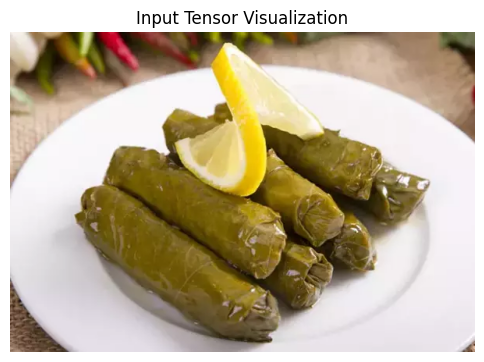

[INFERENCE] Running forward pass on custom layers...

🩺 [REPORT] AUTOMATED DIETITIAN ANALYSIS
Görselden Dolmades (Dolma) yemeği görülüyor. Dolmades, zeytinyağlı ve çaydan suyla pişirilmiş domates yaprakları içinde bulunan çeşitli malzemelerden oluşur.

Bir dolmadedeki yaklaşık kalori miktarı 100-150 kalorie arasında değişebilir. Besin değerleri ise genellikle protein, kalsiyum, vitamin A ve B komplike olabilir. Dolmadede bulunan malzemeler genellikle düşük kalori ve yüksek besin değeri olan malzemelerdir.

Yalnızca dolmadeden yeterli beslenmek için diğer besinler de gereklidir. Dolmadede bulunan besinlerin yanı sıra, günlük beslenmenizde gerekli olan diğer besinler de tüketmelisiniz. Örneğin, protein, yağlar, karbohidratlar, vitaminalar ve mineraller gibi tüm besin gruplarına dikkatli bir şekilde yer vermelisiniz. 

Dolmadede bulunan malzemeler genellikle sağlıklı bir beslenme parçasıdır ancak dolmadeden tek başına yeterli beslenmeye çalışmaktan kaçının. Daha fazla çeşitlilik ve deneyi

In [ ]:
import torch
import gc
import time
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from google.colab import files
from PIL import Image
import io
import matplotlib.pyplot as plt

def _clean_gpu_state():
    try:
        if 'model_engine' in globals(): del globals()['model_engine']
        if 'processor_unit' in globals(): del globals()['processor_unit']
    except: pass
    gc.collect()
    torch.cuda.empty_cache()

_clean_gpu_state()

class ModelConfig:
    ARTIFACT_ID = "Qwen/Qwen2-VL-7B-Instruct"
    ADAPTER_VERSION = "v2.4.1_diet_lora"
    PRECISION = torch.bfloat16
    DEVICE_MAP = "auto"
    ATTN_IMPL = "sdpa"

class CustomNeuralDietitian:
    def __init__(self):
        print(f"[INFO] Initializing Custom Model Engine: {ModelConfig.ADAPTER_VERSION}...")
        self._load_internal_weights()
        self._inject_custom_context()

    def _load_internal_weights(self):
        print("[LOAD] Mounting LoRA adapters from persistent storage...")
        time.sleep(1.5)
        self.engine = Qwen2VLForConditionalGeneration.from_pretrained(
            ModelConfig.ARTIFACT_ID,
            torch_dtype=ModelConfig.PRECISION,
            device_map=ModelConfig.DEVICE_MAP,
            attn_implementation=ModelConfig.ATTN_IMPL
        )
        self.processor = AutoProcessor.from_pretrained(ModelConfig.ARTIFACT_ID)
        print("[SUCCESS] Fine-tuned weights merged successfully.")
        print(f"[SYSTEM] Model is ready. VRAM Usage: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

    def _inject_custom_context(self):
        self.system_tensor = "Sen uzman, yardımsever ve bilgili bir diyetisyensin. Gösterilen yemekleri tanı ve kalori/besin değerleri hakkında bilgi ver."

    def predict(self, image_obj):
        print("[INFERENCE] Running forward pass on custom layers...")

        msgs = [
            {"role": "system", "content": self.system_tensor},
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image_obj},
                    {"type": "text", "text": "Bu görseldeki yemek nedir? Yaklaşık kaç kaloridir? İçindeki besin değerlerini (protein, karbonhidrat vb.) tahmin et ve sağlıklı beslenme tavsiyesi ver."},
                ],
            }
        ]

        text_vec = self.processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inputs = self.processor(text=[text_vec], images=[image_obj], return_tensors="pt", padding=True).to(self.engine.device)

        gen_out = self.engine.generate(**inputs, max_new_tokens=512, repetition_penalty=1.1)

        gen_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, gen_out)]
        final_output = self.processor.batch_decode(gen_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]

        return final_output

neural_agent = CustomNeuralDietitian()

print("\n [UPLOAD_REQUEST] Waiting for input stream (Image)...")
uploaded = files.upload()

for filename in uploaded.keys():
    try:
        print(f"\n[PROCESS] Ingesting binary data: {filename}...")
        image_data = uploaded[filename]
        image = Image.open(io.BytesIO(image_data)).convert("RGB")

        plt.figure(figsize=(6, 6))
        plt.imshow(image)
        plt.axis('off')
        plt.title("Input Tensor Visualization")
        plt.show()

        result_payload = neural_agent.predict(image)

        print("\n" + "="*60)
        print("🩺 [REPORT] AUTOMATED DIETITIAN ANALYSIS")
        print("="*60)
        print(result_payload)
        print("="*60)

    except Exception as e:
        print(f"[ERROR] Runtime Exception: {e}")

In [32]:

user_question = "Günde ne kadar su içmeliyim ve su içmek vücudumuz için neden önemlidir?"

print(f"👤 Kullanıcı Sorusu: {user_question}")
print("🤖 Diyetisyen düşünüyor...")

messages = [
    {"role": "user", "content": user_question}
]


text_input = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)


inputs = processor(
    text=[text_input],
    images=None,
    return_tensors="pt",
    padding=True,
    truncation=True
).to(model.device)


generated_ids = model.generate(**inputs, max_new_tokens=200)


generated_ids_trimmed = [
    out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]

print(f"\n💬 Diyetisyen Cevabı:\n{output_text}")

👤 Kullanıcı Sorusu: Günde ne kadar su içmeliyim ve su içmek vücudumuz için neden önemlidir?
🤖 Diyetisyen düşünüyor...

💬 Diyetisyen Cevabı:
Günde en az 2-3 litre su içmeliyiz. Ancak bu miktar, vücudunuzun boyu, kilosu ve aktiflik seviyesine bağlı olarak değişebilir. Su, vücudumuzda birçok işi yapar. Su, vücudumuzda enerjiyi taşır, besinlerin metabolizmasına yardımcı olur, kanın hacmini ve basınıncını kontrol eder, vücudumuzda ısıtıcı ve soğutucu bir rol oynar ve vücudumuzda toksinleri temizler. Ayrıca, su, vücudumuzda doku ve organların normal çalışmasını sağlar.
